In [1]:
import sys
import pandas as pd
from matplotlib import pyplot as plt
import copy

sys.path.insert(1, '../src')
from backtest import Backtest
from optimization import *
from constraints import Constraints

import quantstats as qs
qs.extend_pandas()

from backtest import (
    Backtest,
    BacktestService,
    BacktestData,
    append_custom,
)
from optimization import LeastSquares
from constraints import Constraints
from builders import (
    SelectionItemBuilder,
    OptimizationItemBuilder,
    bibfn_selection_data,
    bibfn_return_series,
    bibfn_bm_series,
    bibfn_budget_constraint,
    bibfn_box_constraints,
)

from report import BacktestReporter

In [2]:
path = '../data/'  # Change this to your path

# Prepare data
return_series = pd.read_parquet(f'{path}usa_returns.parquet')
bm_return_series = pd.read_csv(f'{path}SPTR.csv', index_col = 0)
bm_return_series.index = pd.to_datetime(bm_return_series.index, format='%d/%m/%Y')
features = pd.read_parquet(f'{path}usa_features.parquet')
data = OptimizationData(return_series = return_series, bm_series = bm_return_series, align = True)

In [3]:
# Define rebalancing dates
n_days = 21
start_date = '2023-01-01'
dates = data['return_series'].index
rebdates = dates[dates > start_date][::n_days].strftime('%Y-%m-%d').tolist()
width = 252

In [4]:
# Selection builders 
selection_item_builders = {
    'data': SelectionItemBuilder(bibfn=bibfn_selection_data),
}

# Optimization builders 
optimization_item_builders = {
    'return_series':     OptimizationItemBuilder(bibfn=bibfn_return_series, width=width),
    'bm_series':         OptimizationItemBuilder(bibfn=bibfn_bm_series, width=width),
    'budget_constraint': OptimizationItemBuilder(bibfn=bibfn_budget_constraint, budget=1),
    'box_constraints':   OptimizationItemBuilder(bibfn=bibfn_box_constraints, box_type='LongOnly'),
}

bs = BacktestService(
    data=data,
    selection_item_builders=selection_item_builders,
    optimization_item_builders=optimization_item_builders,
    rebdates=rebdates,
)

In [5]:
def run_backtest(bs, optimization=None):
    bs_copy = copy.deepcopy(bs)

    if optimization is not None:
        bs_copy.optimization = optimization

    bt = Backtest()
    bt.run(bs=bs_copy)

    return bt

# Simulation
def simulation(bt):
    sim_bt = bt.strategy.simulate(return_series = data['return_series'],  
                                fc = 0,
                                vc = 0)
    print(f'Simulation period: {sim_bt.index[0].date()} → {sim_bt.index[-1].date()}')
    return sim_bt

In [6]:
models = {"QEQW": QEQW(), 
          "LAD": LAD(solver_name='cvxopt'), 
          "LS": LeastSquares(solver_name='cvxopt'), 
          "WLS": WeightedLeastSquares(solver_name='cvxopt', tau=252),
          "MV": MeanVariance(risk_aversion=4),
          "PP": PercentilePortfolios()
          }

In [7]:
bts = {}

for name, model in models.items():
    bts[name] = run_backtest(bs, model)

Rebalancing date: 2023-01-03
Rebalancing date: 2023-02-02
Rebalancing date: 2023-03-06
Rebalancing date: 2023-04-04
Rebalancing date: 2023-05-04
Rebalancing date: 2023-06-05
Rebalancing date: 2023-01-03
Rebalancing date: 2023-02-02
Rebalancing date: 2023-03-06
Rebalancing date: 2023-04-04
Rebalancing date: 2023-05-04
Rebalancing date: 2023-06-05
Rebalancing date: 2023-01-03
Rebalancing date: 2023-02-02
Rebalancing date: 2023-03-06
Rebalancing date: 2023-04-04
Rebalancing date: 2023-05-04
Rebalancing date: 2023-06-05
Rebalancing date: 2023-01-03
Rebalancing date: 2023-02-02
Rebalancing date: 2023-03-06
Rebalancing date: 2023-04-04
Rebalancing date: 2023-05-04
Rebalancing date: 2023-06-05
Rebalancing date: 2023-01-03
Rebalancing date: 2023-02-02
Rebalancing date: 2023-03-06
Rebalancing date: 2023-04-04
Rebalancing date: 2023-05-04
Rebalancing date: 2023-06-05
Rebalancing date: 2023-01-03
Rebalancing date: 2023-02-02
Rebalancing date: 2023-03-06
Rebalancing date: 2023-04-04
Rebalancing da

In [8]:
summaries = {}
for name, bt in bts.items():
    summary = bt.strategy.number_of_assets()
    summaries[name] = summary

summaries_df = pd.concat(summaries, axis=1)
summaries_df.loc["mean"] = summaries_df.mean(axis=0)
summaries_df

,QEQW,LAD,LS,WLS,MV,PP
2023-01-03,494.0,131.0,135.0,130.000000,9.000000,198.0
2023-02-02,494.0,134.0,141.0,145.000000,10.000000,198.0
2023-03-06,494.0,133.0,147.0,155.000000,8.000000,198.0
2023-04-04,494.0,144.0,135.0,136.000000,8.000000,198.0
2023-05-04,494.0,137.0,152.0,158.000000,8.000000,198.0
2023-06-05,494.0,134.0,145.0,144.000000,7.000000,198.0
mean,494.0,135.5,142.5,144.666667,8.333333,198.0


In [9]:
sim_results = {}

for name, bt in bts.items():
    sim_results[name] = simulation(bt)

lad_index = sim_results['LAD'].index
benchmark_data = data['bm_series'].loc[data['bm_series'].index.isin(lad_index)]
sim_results['benchmark'] = benchmark_data['SPTR']

Simulation period: 2023-01-04 → 2023-06-06
Simulation period: 2023-01-04 → 2023-06-06
Simulation period: 2023-01-04 → 2023-06-06
Simulation period: 2023-01-04 → 2023-06-06
Simulation period: 2023-01-04 → 2023-06-06
Simulation period: 2023-01-04 → 2023-06-06



===== METRICS =====
           Return (%)  Volatility (%)  Sharpe  Calmar  Max Drawdown (%)  \
benchmark      12.857          15.093   1.848   1.708            -7.528   
LAD            10.402          15.485   1.467   1.229            -8.461   
LS             10.118          15.603   1.418   1.093            -9.255   
WLS             9.831          15.582   1.380   1.057            -9.302   
QEQW            1.228          17.712   0.139   0.097           -12.666   
MV             -1.683          16.645  -0.280  -0.142           -11.825   
PP             -6.874          19.982  -0.847  -0.432           -15.922   

           Win Rate (%)  VaR (95%)  
benchmark        52.830     -1.507  
LAD              52.830     -1.500  
LS               52.830     -1.565  
WLS              52.830     -1.559  
QEQW             47.170     -1.859  
MV               50.000     -2.040  
PP               53.774     -2.287  


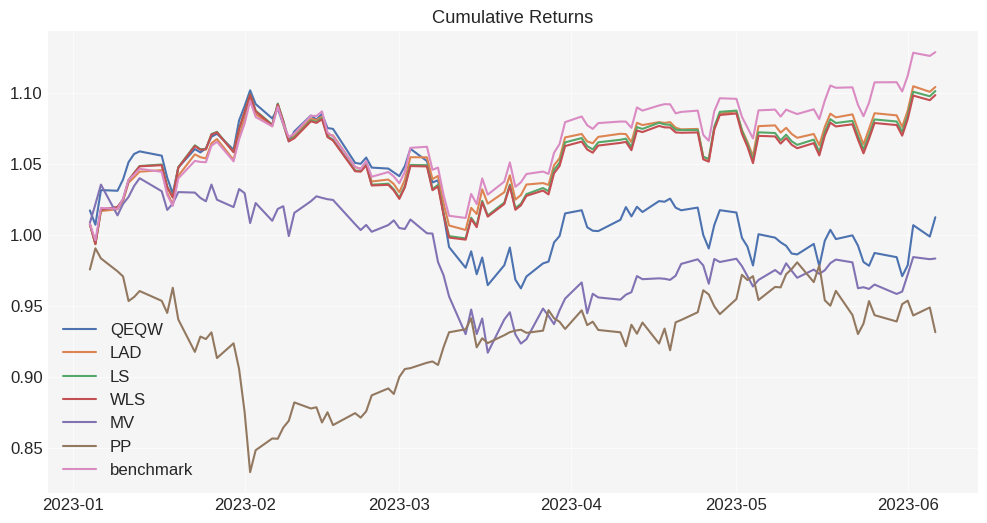

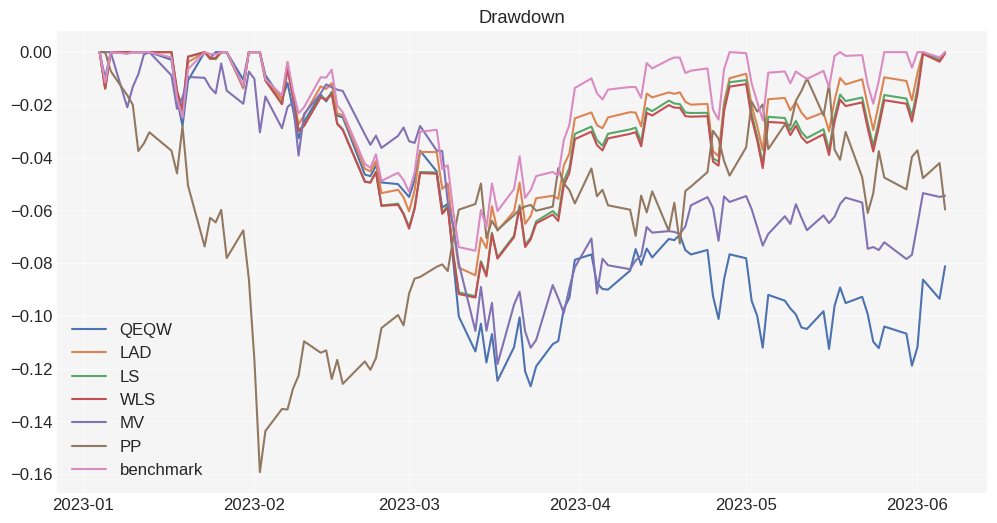

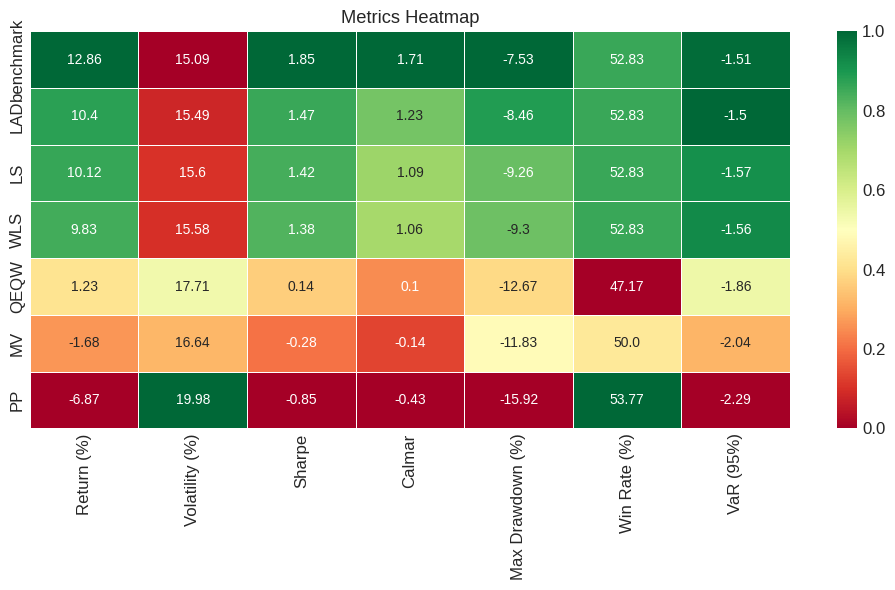

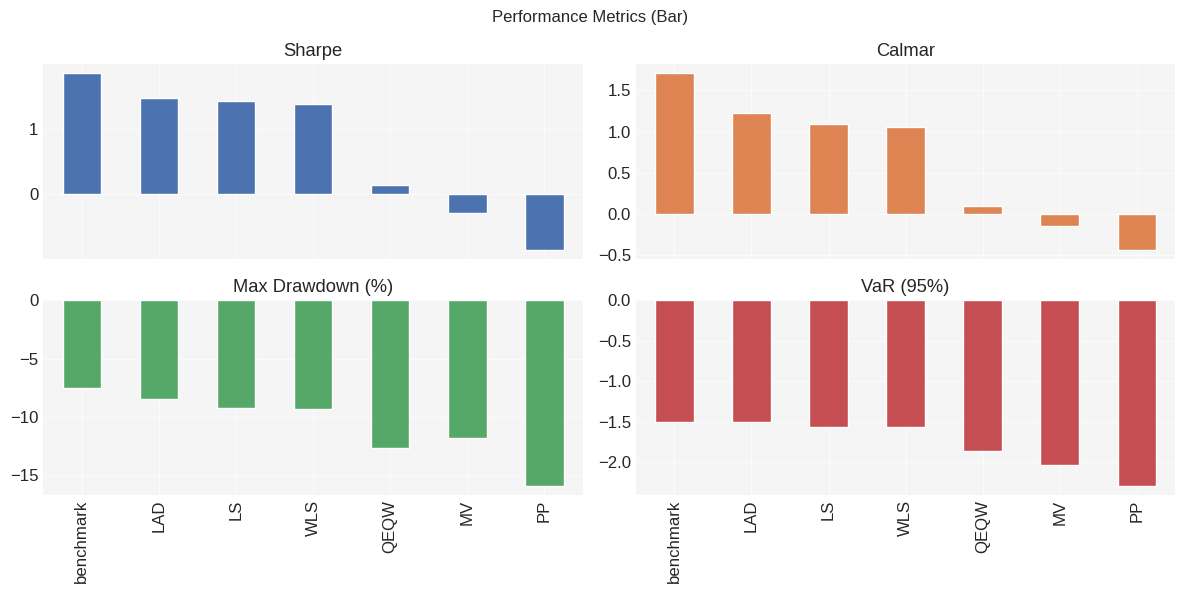

In [10]:
reporter = BacktestReporter()
metrics = reporter.run(sim_results)